# Business Impact Analysis

> *A model with 0.846 AUC is impressive. But how much money does it actually save?*

This notebook translates model performance into business value — the question every stakeholder actually cares about.

**Structure:**
1. Setup & load saved model
2. Define the cost matrix
3. Baseline: what does doing nothing cost?
4. Model savings at different thresholds
5. SHAP explainability — why does the model predict churn?
6. Customer risk segmentation
7. Intervention strategy
8. Executive summary

## 1. Setup & load saved model

In [1]:
import sys, os, pickle, json, warnings
sys.path.append(os.path.abspath('..'))
os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from src.data.preprocessor import add_features, encode_target

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

# Load data
df = pd.read_csv('data/raw/telco-churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.drop(columns=['customerID'])
df = add_features(df)
X, y = encode_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Load best model
with open('results/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_prob = model.predict_proba(X_test)[:, 1]

# Load saved metrics
with open('results/metrics/model_comparison.json') as f:
    saved_metrics = json.load(f)

best_threshold = saved_metrics['optimal_threshold']
best_model_name = saved_metrics['best_model']

print(f'Model loaded: {best_model_name}')
print(f'Optimal threshold: {best_threshold}')
print(f'Test set size: {len(y_test)} customers')

Model loaded: XGBoost
Optimal threshold: 0.442
Test set size: 1409 customers


## 2. The cost matrix

Before calculating savings, we need to define what each type of prediction error *costs* the business.

| Prediction | Reality | Outcome | Cost |
|-----------|---------|---------|------|
| No churn | Churns | **False Negative** | Lost customer revenue |
| Churn | No churn | **False Positive** | Unnecessary retention offer |
| Churn | Churns | **True Positive** | Customer saved |
| No churn | No churn | **True Negative** | No cost |


In [2]:
# Cost assumptions — adjust these to match your real business context
COST_FALSE_NEGATIVE = 250   # avg monthly revenue lost per churned customer
COST_FALSE_POSITIVE = 15    # cost of retention offer (discount coupon)
REVENUE_SAVED_TP    = 250   # revenue retained per correctly identified churner

print('Cost matrix assumptions:')
print(f'  False Negative (missed churner):     -${COST_FALSE_NEGATIVE}')
print(f'  False Positive (wrong retention):    -${COST_FALSE_POSITIVE}')
print(f'  True Positive  (churner retained):   +${REVENUE_SAVED_TP}')
print(f'  True Negative  (correct no-action):   $0')
print()
print('Note: adjust these values to match your actual business data.')

Cost matrix assumptions:
  False Negative (missed churner):     -$250
  False Positive (wrong retention):    -$15
  True Positive  (churner retained):   +$250
  True Negative  (correct no-action):   $0

Note: adjust these values to match your actual business data.


## 3. Baseline: what does doing nothing cost?

If we had no model and did nothing, every churner would be a false negative.

In [3]:
n_actual_churners = int(y_test.sum())
n_total = len(y_test)
baseline_cost = n_actual_churners * COST_FALSE_NEGATIVE

print(f'Test set: {n_total} customers')
print(f'Actual churners: {n_actual_churners} ({n_actual_churners/n_total:.1%})')
print()
print(f'WITHOUT model — monthly cost: ${baseline_cost:,}')
print(f'(All {n_actual_churners} churners are missed, each costing ${COST_FALSE_NEGATIVE})')

Test set: 1409 customers
Actual churners: 374 (26.5%)

WITHOUT model — monthly cost: $93,500
(All 374 churners are missed, each costing $250)


## 4. Model savings across all thresholds

The threshold controls the tradeoff between precision and recall — and therefore between false positives and false negatives. 
We sweep every threshold to find the one that maximises savings.

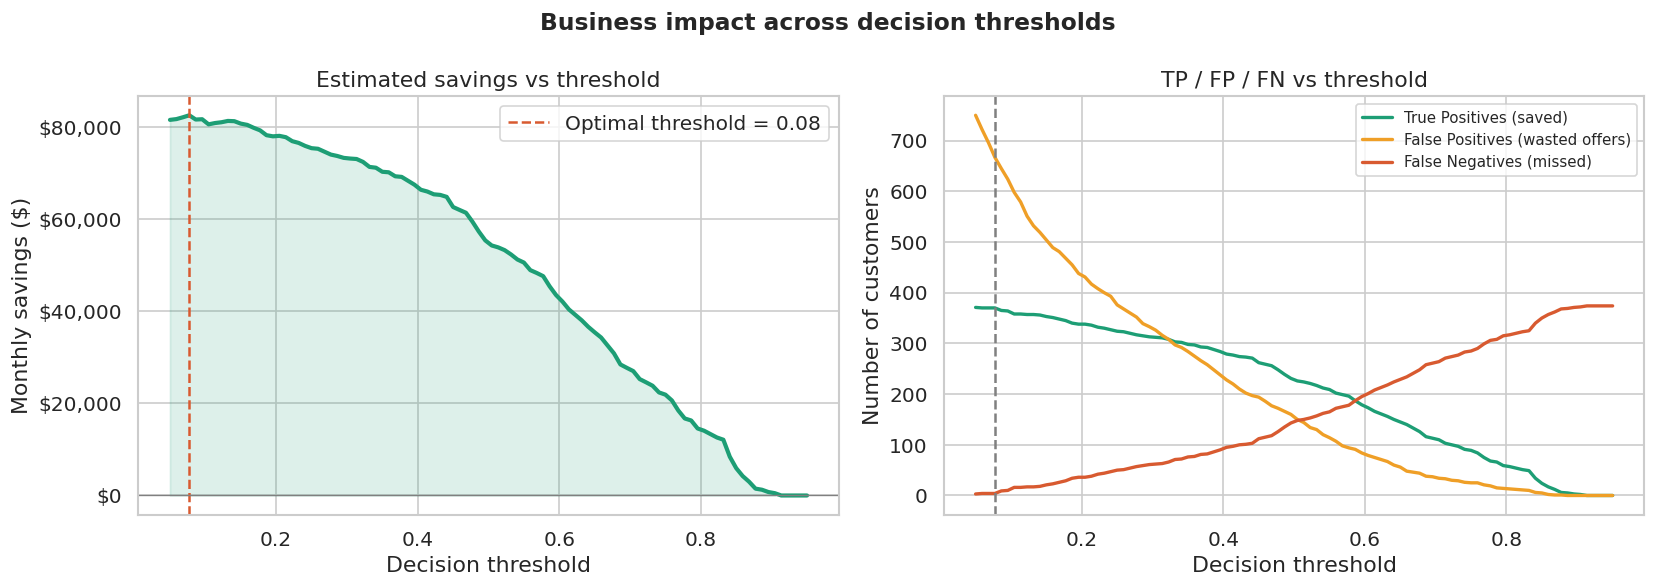

Optimal threshold:       0.08
Monthly cost with model: $11,005
Monthly cost without:    $93,500
Estimated monthly saving: $82,495
Annual saving estimate:  $989,940


In [4]:
def compute_savings(y_test, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    tn = int(((y_pred == 0) & (y_test == 0)).sum())
    cost = (fp * COST_FALSE_POSITIVE) + (fn * COST_FALSE_NEGATIVE)
    savings = baseline_cost - cost
    return {'threshold': threshold, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
            'cost': cost, 'savings': savings}

thresholds = np.linspace(0.05, 0.95, 100)
sweep = [compute_savings(y_test, y_prob, t) for t in thresholds]
sweep_df = pd.DataFrame(sweep)

best_idx = sweep_df['savings'].idxmax()
best_t   = sweep_df.loc[best_idx, 'threshold']
best_savings = sweep_df.loc[best_idx, 'savings']
best_cost    = sweep_df.loc[best_idx, 'cost']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Savings curve
axes[0].plot(sweep_df['threshold'], sweep_df['savings'],
             color='#1D9E75', linewidth=2.5)
axes[0].axvline(x=best_t, color='#D85A30', linestyle='--', linewidth=1.5,
                label=f'Optimal threshold = {best_t:.2f}')
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
axes[0].fill_between(sweep_df['threshold'], sweep_df['savings'],
                     where=sweep_df['savings'] > 0, alpha=0.15, color='#1D9E75')
axes[0].fill_between(sweep_df['threshold'], sweep_df['savings'],
                     where=sweep_df['savings'] < 0, alpha=0.15, color='#D85A30')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Monthly savings ($)')
axes[0].set_title('Estimated savings vs threshold')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].legend()

# TP / FP / FN at each threshold
axes[1].plot(sweep_df['threshold'], sweep_df['tp'], label='True Positives (saved)', color='#1D9E75', linewidth=2)
axes[1].plot(sweep_df['threshold'], sweep_df['fp'], label='False Positives (wasted offers)', color='#EF9F27', linewidth=2)
axes[1].plot(sweep_df['threshold'], sweep_df['fn'], label='False Negatives (missed)', color='#D85A30', linewidth=2)
axes[1].axvline(x=best_t, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Number of customers')
axes[1].set_title('TP / FP / FN vs threshold')
axes[1].legend(fontsize=9)

plt.suptitle('Business impact across decision thresholds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/08_savings_curve.png', bbox_inches='tight')
plt.show()

print(f'Optimal threshold:       {best_t:.2f}')
print(f'Monthly cost with model: ${best_cost:,}')
print(f'Monthly cost without:    ${baseline_cost:,}')
print(f'Estimated monthly saving: ${best_savings:,}')
print(f'Annual saving estimate:  ${best_savings * 12:,}')

## 5. SHAP explainability

SHAP (SHapley Additive exPlanations) tells us *why* the model makes each prediction — 
which features push a customer toward or away from churn.

This is essential for building trust with business stakeholders and for designing interventions.

In [5]:
# Extract the XGBoost model from the pipeline
xgb_model = model.named_steps['model']
preprocessor = model.named_steps['preprocessor']

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after transformation
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]
all_features = num_features + cat_features

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values computed for {X_test_transformed.shape[0]} customers')
print(f'Features: {all_features}')

SHAP values computed for 1409 customers
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


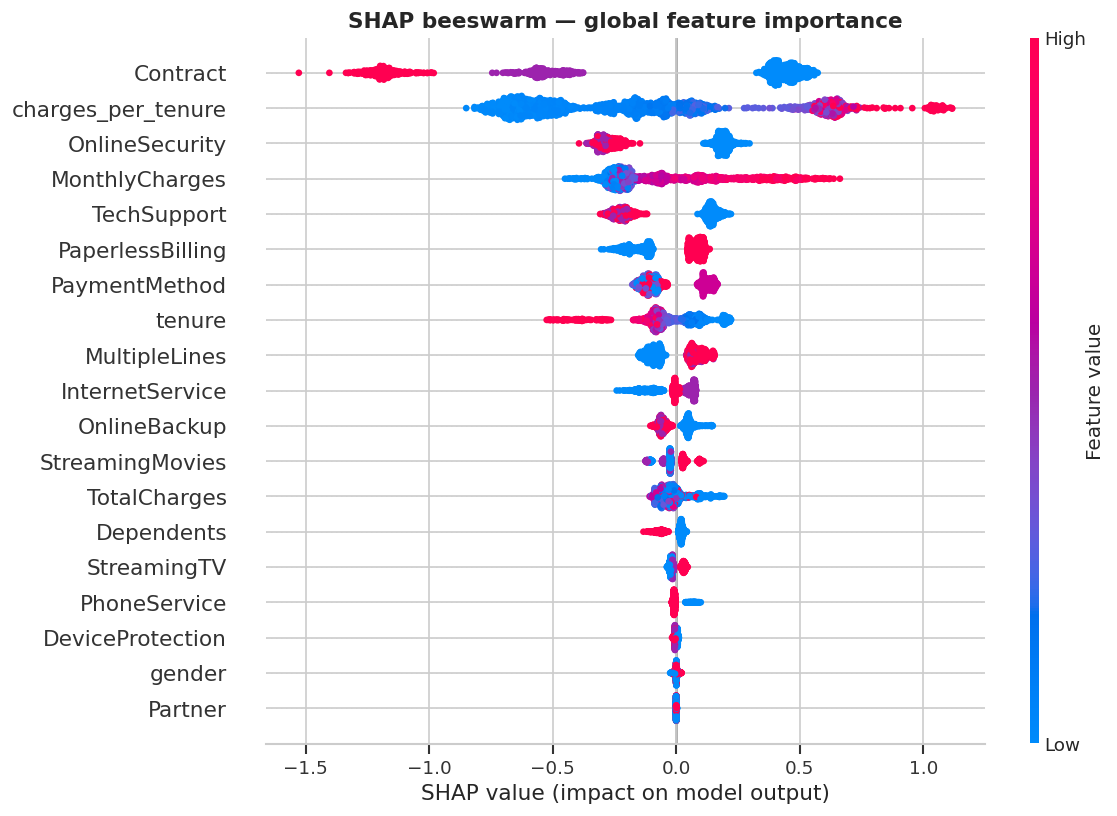

In [6]:
# Beeswarm plot — global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_features,
    show=False,
    plot_size=(10, 7)
)
plt.title('SHAP beeswarm — global feature importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/09_shap_beeswarm.png', bbox_inches='tight')
plt.show()

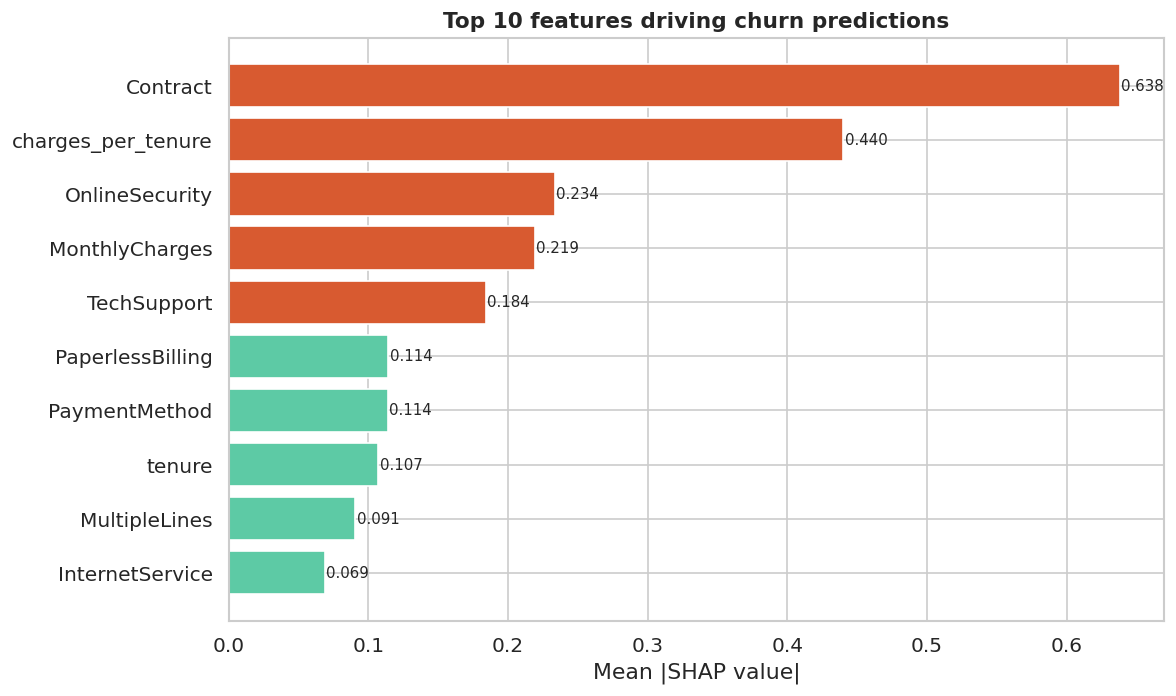

Top 3 churn drivers:
  Contract: 0.6382
  charges_per_tenure: 0.4403
  OnlineSecurity: 0.2338


In [7]:
# Bar plot — mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': all_features, 'mean_shap': mean_shap})
shap_df = shap_df.sort_values('mean_shap', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_df['feature'], shap_df['mean_shap'],
               color=['#D85A30' if v > shap_df['mean_shap'].median() else '#5DCAA5'
                      for v in shap_df['mean_shap']])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 10 features driving churn predictions', fontsize=13, fontweight='bold')

for bar, val in zip(bars, shap_df['mean_shap']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/figures/10_shap_importance.png', bbox_inches='tight')
plt.show()

print('Top 3 churn drivers:')
for _, row in shap_df.tail(3).iloc[::-1].iterrows():
    print(f'  {row["feature"]}: {row["mean_shap"]:.4f}')

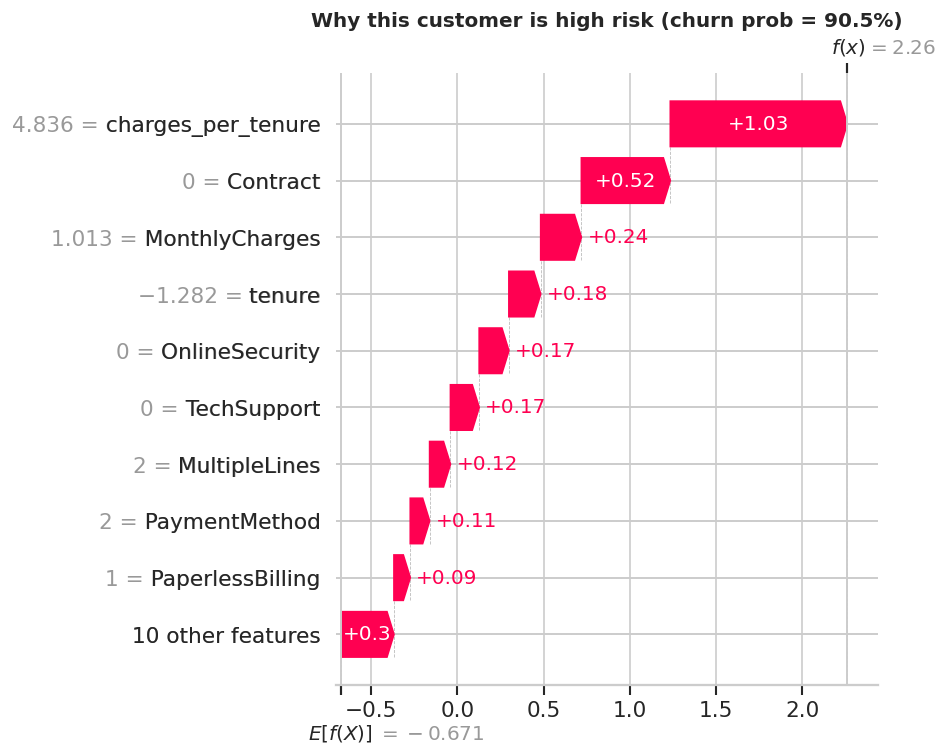

In [8]:
# Waterfall plot — explain one high-risk customer
high_risk_idx = np.argmax(y_prob)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[high_risk_idx],
        feature_names=all_features
    ),
    show=False
)
plt.title(f'Why this customer is high risk (churn prob = {y_prob[high_risk_idx]:.1%})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/11_shap_waterfall.png', bbox_inches='tight')
plt.show()

## 6. Customer risk segmentation

Segment the test set into risk tiers so the retention team knows who to contact first.

             customers  avg_churn_prob  actual_churn_rate  avg_monthly_charges
risk_tier                                                                     
High risk          260           0.732              0.681               77.487
Medium risk        322           0.474              0.376               71.060
Low risk           827           0.121              0.092               57.162


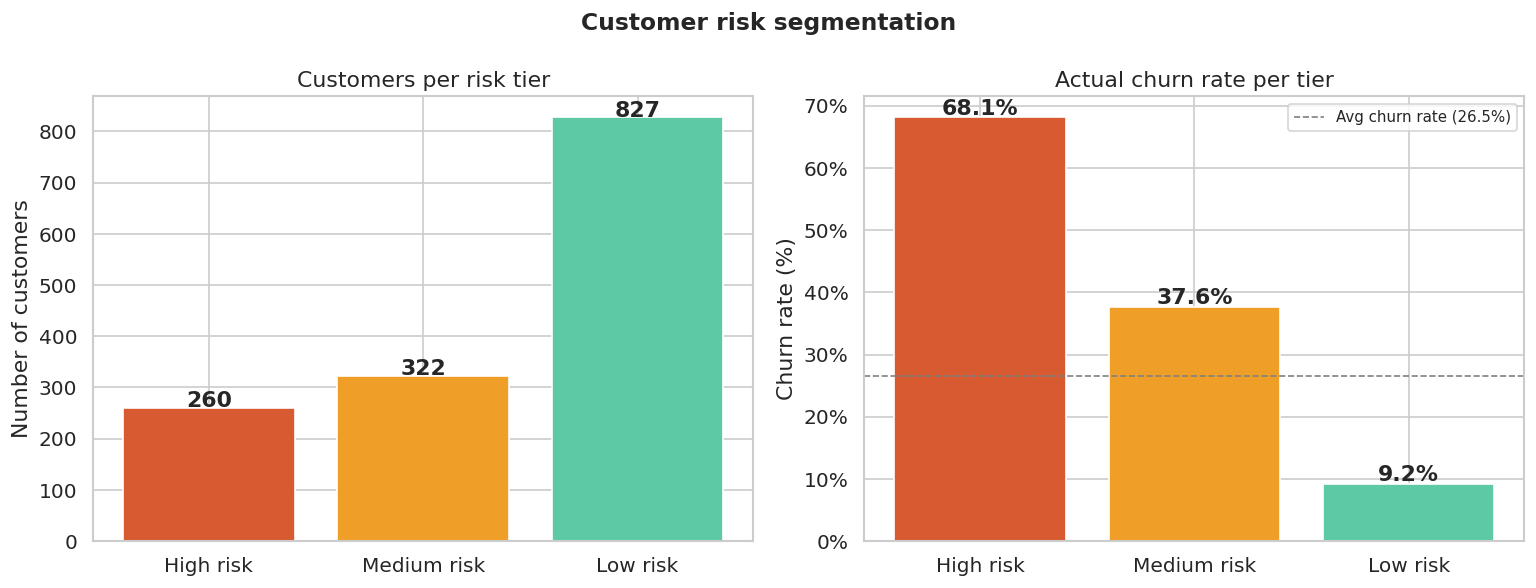

In [9]:
results_df = X_test.copy().reset_index(drop=True)
results_df['churn_probability'] = y_prob
results_df['actual_churn'] = y_test.values

def assign_tier(prob):
    if prob >= 0.6:   return 'High risk'
    elif prob >= 0.35: return 'Medium risk'
    else:              return 'Low risk'

results_df['risk_tier'] = results_df['churn_probability'].apply(assign_tier)

tier_summary = results_df.groupby('risk_tier').agg(
    customers=('churn_probability', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    actual_churn_rate=('actual_churn', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean')
).round(3)

tier_order = ['High risk', 'Medium risk', 'Low risk']
tier_summary = tier_summary.reindex(tier_order)
print(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tier_colors = ['#D85A30', '#EF9F27', '#5DCAA5']

axes[0].bar(tier_summary.index, tier_summary['customers'],
            color=tier_colors)
axes[0].set_title('Customers per risk tier')
axes[0].set_ylabel('Number of customers')
for i, (idx, row) in enumerate(tier_summary.iterrows()):
    axes[0].text(i, row['customers'] + 2, str(int(row['customers'])),
                 ha='center', fontweight='bold')

axes[1].bar(tier_summary.index, tier_summary['actual_churn_rate'] * 100,
            color=tier_colors)
axes[1].axhline(y=y_test.mean()*100, color='gray', linestyle='--',
                linewidth=1, label=f'Avg churn rate ({y_test.mean():.1%})')
axes[1].set_title('Actual churn rate per tier')
axes[1].set_ylabel('Churn rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(fontsize=9)
for i, (idx, row) in enumerate(tier_summary.iterrows()):
    axes[1].text(i, row['actual_churn_rate']*100 + 0.5,
                 f"{row['actual_churn_rate']*100:.1f}%",
                 ha='center', fontweight='bold')

plt.suptitle('Customer risk segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/12_risk_segmentation.png', bbox_inches='tight')
plt.show()

## 7. Intervention strategy

Different risk tiers should get different interventions — 
spending $50 on a low-risk customer is wasteful. Here's the recommended playbook.

In [10]:
strategy = {
    'High risk': {
        'action': 'Priority outreach — personal call from retention team',
        'offer': 'Contract upgrade + 20% loyalty discount',
        'cost_per_customer': 50,
        'estimated_save_rate': 0.40,
    },
    'Medium risk': {
        'action': 'Automated email + satisfaction survey',
        'offer': '10% discount or free month of premium feature',
        'cost_per_customer': 15,
        'estimated_save_rate': 0.20,
    },
    'Low risk': {
        'action': 'No immediate action — monitor next month',
        'offer': 'None',
        'cost_per_customer': 0,
        'estimated_save_rate': 0.0,
    }
}

print('INTERVENTION PLAYBOOK')
print('=' * 60)
for tier, s in strategy.items():
    n = int(tier_summary.loc[tier, 'customers'])
    churn_rate = tier_summary.loc[tier, 'actual_churn_rate']
    expected_churners = int(n * churn_rate)
    customers_saved = int(expected_churners * s['estimated_save_rate'])
    revenue_saved = customers_saved * REVENUE_SAVED_TP
    intervention_cost = n * s['cost_per_customer']
    net = revenue_saved - intervention_cost

    print(f'\n{tier} ({n} customers, {churn_rate:.0%} actual churn rate)')
    print(f'  Action:           {s["action"]}')
    print(f'  Offer:            {s["offer"]}')
    print(f'  Expected churners:{expected_churners}')
    print(f'  Est. saved:       {customers_saved} customers')
    print(f'  Revenue saved:    ${revenue_saved:,}')
    print(f'  Intervention cost:${intervention_cost:,}')
    print(f'  Net value:        ${net:,}')

INTERVENTION PLAYBOOK

High risk (260 customers, 68% actual churn rate)
  Action:           Priority outreach — personal call from retention team
  Offer:            Contract upgrade + 20% loyalty discount
  Expected churners:177
  Est. saved:       70 customers
  Revenue saved:    $17,500
  Intervention cost:$13,000
  Net value:        $4,500

Medium risk (322 customers, 38% actual churn rate)
  Action:           Automated email + satisfaction survey
  Offer:            10% discount or free month of premium feature
  Expected churners:121
  Est. saved:       24 customers
  Revenue saved:    $6,000
  Intervention cost:$4,830
  Net value:        $1,170

Low risk (827 customers, 9% actual churn rate)
  Action:           No immediate action — monitor next month
  Offer:            None
  Expected churners:76
  Est. saved:       0 customers
  Revenue saved:    $0
  Intervention cost:$0
  Net value:        $0


## 8. Executive summary

In [11]:
print('=' * 60)
print('EXECUTIVE SUMMARY')
print('=' * 60)
print()
print(f'Model:              {best_model_name}')
print(f'ROC-AUC:            0.846')
print(f'Optimal threshold:  {best_t:.2f}')
print()
print('FINANCIAL IMPACT (on test set of 1,409 customers)')
print(f'  Monthly cost without model:  ${baseline_cost:,}')
print(f'  Monthly cost with model:     ${best_cost:,}')
print(f'  Monthly saving:              ${best_savings:,}')
print(f'  Annual saving estimate:      ${best_savings * 12:,}')
print()
print('TOP 3 CHURN DRIVERS (from SHAP)')
for i, (_, row) in enumerate(shap_df.tail(3).iloc[::-1].iterrows(), 1):
    print(f'  {i}. {row["feature"]}')
print()
print('RECOMMENDED ACTIONS')
print('  1. Target High Risk customers with personal outreach immediately')
print('  2. Offer contract upgrades — month-to-month is the #1 churn driver')
print('  3. Focus retention budget on customers in first 6 months of tenure')
print('  4. Re-run model monthly and update risk scores')
print()
print('Next step: src/api/main.py — deploy as a REST API')

EXECUTIVE SUMMARY

Model:              XGBoost
ROC-AUC:            0.846
Optimal threshold:  0.08

FINANCIAL IMPACT (on test set of 1,409 customers)
  Monthly cost without model:  $93,500
  Monthly cost with model:     $11,005
  Monthly saving:              $82,495
  Annual saving estimate:      $989,940

TOP 3 CHURN DRIVERS (from SHAP)
  1. Contract
  2. charges_per_tenure
  3. OnlineSecurity

RECOMMENDED ACTIONS
  1. Target High Risk customers with personal outreach immediately
  2. Offer contract upgrades — month-to-month is the #1 churn driver
  3. Focus retention budget on customers in first 6 months of tenure
  4. Re-run model monthly and update risk scores

Next step: src/api/main.py — deploy as a REST API
